In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
data=pd.read_csv('data_orphans_127_v20241218.csv',sep=';')

In [3]:
data.head()

,indicator_code,year,region,okato,oktmo,indicator_category,dimension,main_level,indicator,indicator_value
0,q913103rik000001,2014,Республика Адыгея,79000000,79000000,"1. Учет и устройство детей, оставшихся без поп...",всего,"детей выявлено и учтено, всего, на конец отчет...","детей, оставшихся неустроенными к началу отчет...",1
1,q913103rik000002,2014,Республика Адыгея,79000000,79000000,"1. Учет и устройство детей, оставшихся без поп...",всего,"детей выявлено и учтено, всего, на конец отчет...","детей, выявленных и учтенных за отчетный год",172
2,q913103rik000003,2014,Республика Адыгея,79000000,79000000,"1. Учет и устройство детей, оставшихся без поп...",всего,"детей, выявленных и учтенных за отчетный год",детей-сирот,31
3,q913103rik000004,2014,Республика Адыгея,79000000,79000000,"1. Учет и устройство детей, оставшихся без поп...",всего,"детей, выявленных и учтенных за отчетный год",в возрасте до 7 лет,51
4,q913103rik000005,2014,Республика Адыгея,79000000,79000000,"1. Учет и устройство детей, оставшихся без поп...",всего,"детей, выявленных и учтенных за отчетный год",девочек (девушек),76


In [4]:
np.array(data["indicator"].unique())

array(['детей, оставшихся неустроенными к началу отчетного года',
       'детей, выявленных и учтенных за отчетный год', 'детей-сирот',
       'в возрасте до 7 лет', 'девочек (девушек)',
       'детей выявлено и учтено, всего, на конец отчетного года',
       'в образовательные организации', 'в медицинские организации ',
       'в организации, оказывающие социальные услуги',
       'в негосударственные организации', 'в детские дома семейного типа',
       'под предварительную опеку (попечительство)',
       'находятся под предварительной опекой на конец отчетного года',
       'по истечении установленного срока были помещены под надзор в организацию для детей-сирот',
       'по истечении установленного срока переданы на безвозмездную форму опеки (попечительства) в семью предварительного опекуна',
       'по истечении установленного срока переданы на возмездную форму опеки (попечительства) в семью предварительного опекуна',
       'в приемную семью', 'в патронатную семью',
       'по ис

In [5]:
regions=data[["region","okato"]].drop_duplicates()


In [6]:
pd.set_option("display.max_rows",200)
pd.set_option("display.max_colwidth",300)

In [7]:
regions

,region,okato
0,Республика Адыгея,79000000
41,Республика Алтай,84000000
82,Республика Башкортостан,80000000
123,Республика Бурятия,81000000
164,Республика Дагестан,82000000
205,Республика Ингушетия,26000000
246,Кабардино-Балкарская Республика,83000000
287,Республика Калмыкия,85000000
328,Карачаево-Черкесская Республика,91000000
369,Республика Карелия,86000000


In [8]:
data["indicator_value"].dtype

dtype('int64')

In [9]:
np.array(data["dimension"].unique())

array(['всего', 'Опекаемые (подопечные), всего',
       'Опекаемые (подопечные) посторонними гражданами',
       'Опекаемые (подопечные) добровольно переданные родителями по заявлению о назначении их ребенку опекуна (попечителя)',
       'Опекаемые (подопечные), на которых выплачиваются денежные средства',
       'Опекаемые (подопечные), переданные под предварительную опеку (попечительство)',
       'Опекаемые (подопечные), переданные на безвозмездную форму опеки (попечительства)',
       'Опекаемые (подопечные), переданные на возмездную форму опеки (попечительства), по договору о приемной семье',
       'Опекаемые (подопечные), переданные на возмездную форму опеки (попечительства), по договору о патронатной семье (в случаях, предусмотренных законами субъектов РФ)',
       'Опекаемые (подопечные), переданные на возмездную форму опеки (попечительства), на иные виды возмездной опеки (попечительства)',
       'Усыновленные, кроме усыновленных отчимами и мачехами, всего',
       'Усыновлен

In [10]:
np.array(data["indicator_category"].unique())

array(['1. Учет и устройство детей, оставшихся без попечения родителей',
       '2. Движение численности детей, находящихся на воспитании в семьях, за предыдущий год',
       '3. Устройство детей в семьи',
       '4. Граждан, желающих принять ребенка на воспитание в семьи',
       '5. Зашита прав детей', '6. Специалисты по охране детства'],
      dtype=object)

In [11]:
det_sir_god=data[(data.indicator=="детей-сирот")& (~data.region.str.contains("Российская Федерация"))].groupby("year")["indicator_value"].sum().reset_index()

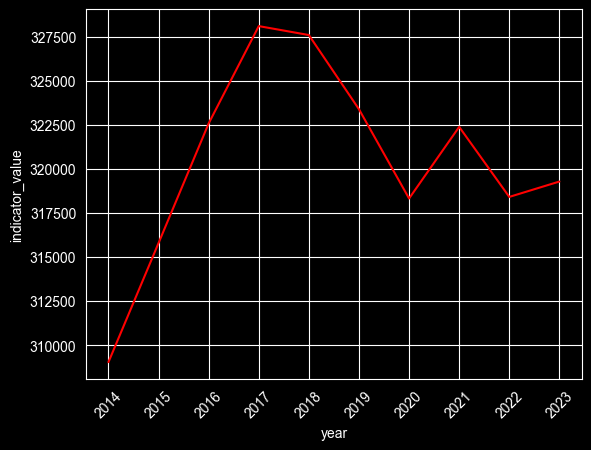

In [12]:
sns.lineplot(det_sir_god,x="year",y="indicator_value",color='red')
plt.xticks(det_sir_god["year"],rotation=45)
plt.show()

Мы видим резкий подъем количества детей, оставшихся без попечения родителей, в 2014 году (более чем в 2 раза). Связано это с 2 причинами: 1) гео-политической ситуацией (в том числе - присоединением новых регионов), 2) в 2013 году был принят закон о запрете усыновления сирот из РФ иностранцам (например иностранные граждане усыновили около 3000 сирот из РФ до выхода закона). По графику также видно, что больше резких подъемов в статистике нет.

In [13]:
data[(data.year==2013) & (data.indicator=='иностранными гражданами')]["indicator_value"].sum()

np.int64(3044)

In [14]:
det_bez_popech=data[(data.indicator=='детей, оставшихся без попечения родителей, находящихся под надзором в организациях для детей-сирот и детей, оставшихся без попечения родителей') & (~data.region.str.contains("Российская Федерация"))].groupby("year")["indicator_value"].sum().reset_index()

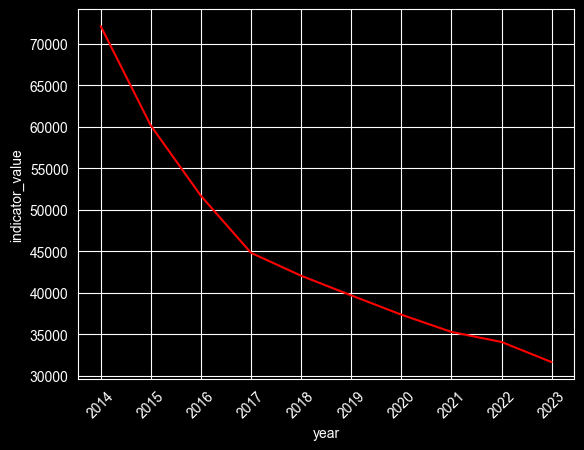

In [15]:
sns.lineplot(det_bez_popech,x="year",y="indicator_value",color='red')
plt.xticks(det_bez_popech["year"],rotation=45)
plt.show()

Видим, опять же, резкий всплеск в 2014 году. Это связано с причинами, указанными выше (законом о запрете усыновления сирот иностранцами и гео-политическими причинами). Также стоит отдельно отметить резкое падение рубля в 2014 году, ввод санкций, повышение безработицы, что также повлияло на увеличение количества детей, оставшихся неустроенными на конец отчетного года (не было экономической стабильности).

In [16]:
det_nujda=data[(data.indicator=='детей, оставшихся неустроенными на конец отчетного года') & (~data.region.str.contains("Российская Федерация"))].groupby("year")["indicator_value"].sum().reset_index()

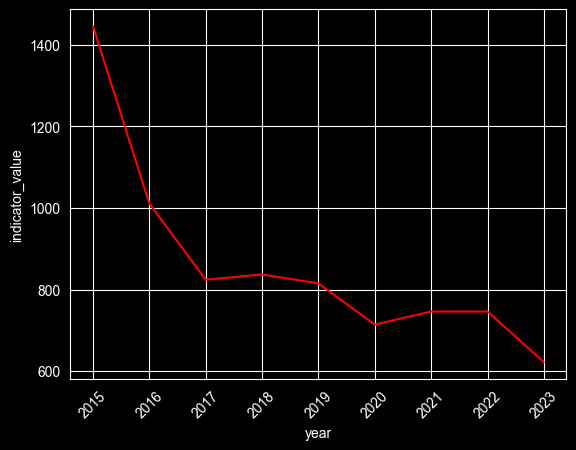

In [17]:
sns.lineplot(det_nujda,x="year",y="indicator_value",color='red')
plt.xticks(det_nujda["year"],rotation=45)
plt.show()

Видим по графику, что после 2015 года пошел резкий спад детей-сирот, выявленных и учтенных на конец отчетного года. Это связано со стабилизацией курса рубля и рынка в целом, падением безработицы.

In [18]:
det_uchet=data[(data.indicator=='детей выявлено и учтено, всего, на конец отчетного года') & (~data.region.str.contains("Российская Федерация"))].groupby("year")["indicator_value"].sum().reset_index()

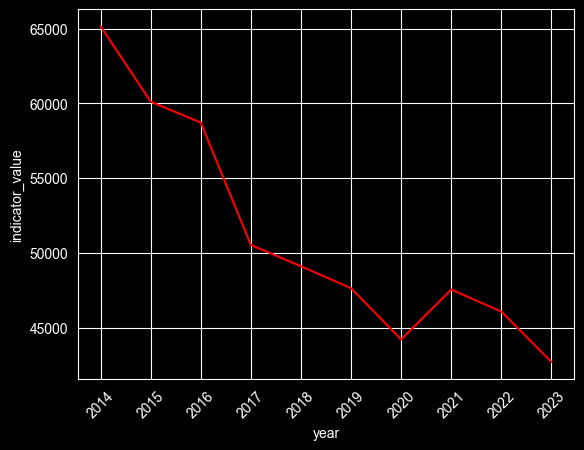

In [19]:
sns.lineplot(det_uchet,x="year",y="indicator_value",color='red')
plt.xticks(det_uchet["year"],rotation=45)
plt.show()

Опять же видим скачек в 2014 году. Здесь играют роль три фактора: 1) указанными выше экономическими проблемами (санкции, падение курса рубля, повышение безработицы) из этого вытекают следующие факторы: 1. уклонения от выполнения родительских обязанностей. 2. если родитель в семье 1: участились случаи, когда родитель не справился со своими обязанностями (в том числе с экономической точки зрения), 2) в 2014 году была изменена форма отчетности (в августе 2013 - одна редакиця, в 2014 - следующая), 3) из 2-го пункта вытекает этот: пересмотр дел 2013 года, из-за чего вердикт об ограничении родительских прав могли пересмотреть, вынести вердикт о полном решении родительских прав.

In [20]:

det_bez_prav=data[((data.indicator=='детей, у которых лишены родительских прав оба родителя или единственный родитель, за отчетный год') | (data.indicator=='детей, у которых ограничены в родительских правах оба родителя или единственный родитель, за отчетный год'))& (~data.region.str.contains("Российская Федерация"))].groupby("year")["indicator_value"].sum().reset_index()

In [21]:
det_bez_prav

,year,indicator_value
0,2021,18914
1,2022,18812
2,2023,16901


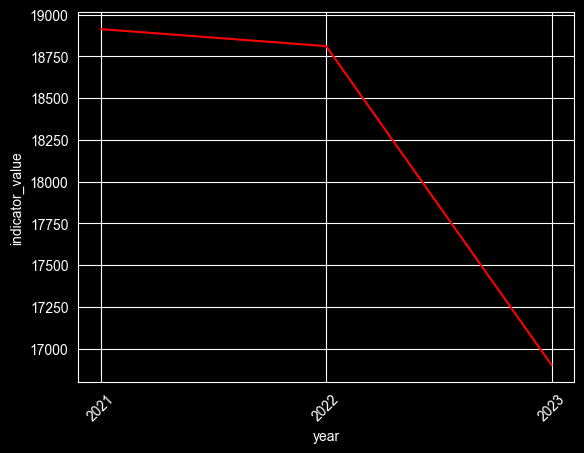

In [22]:
sns.lineplot(det_bez_prav,x="year",y="indicator_value",color='red')
plt.xticks(det_bez_prav["year"],rotation=45)
plt.show()

На графике видим понижение численности специалистов по охране детства к 2023 году. Это объясняется статистикой с прошлых графиков: детей сирот становится меньше, следовательно такие специалисты становятся менее востребованными.

In [23]:
count_spec=data[(data.indicator=='общая численность специалистов по охране детства') & (~data.region.str.contains("Российская Федерация"))].groupby("year")["indicator_value"].sum().reset_index()

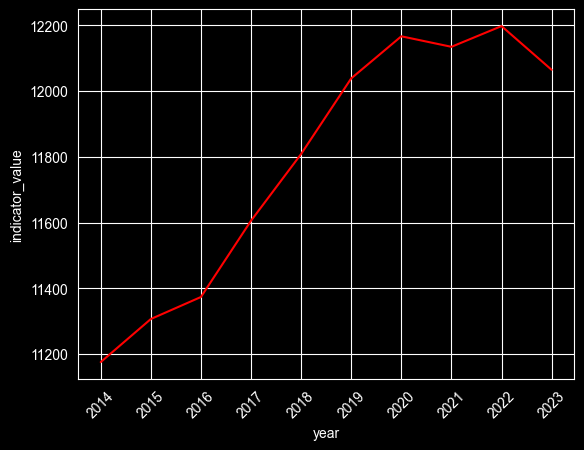

In [24]:
sns.lineplot(count_spec,x="year",y="indicator_value",color='red')
plt.xticks(count_spec["year"],rotation=45)
plt.show()

Наблюдаем рост организаций для детей-сирот в 2014 году (связано с увеличением количества детей-сирот по причинам указанным выше). По графикам выше видно, что такого резкого роста детей-сирот (как в 2014 году) больше не наблюдалось, соответственно и потребность в таких организациях упала. Именно поэтому мы наблюдаем лишь небольшое увеличение количества таких организаций после 2014 года (в 2023 году видим даже небольшое снижение количества таких организаций).

In [25]:
count_spec["indicator_value"].sum()

np.int64(117876)

In [26]:

count_org=data[(data.indicator=='организаций для детей-сирот и детей, оставшихся без попечения родителей')& (~data.region.str.contains("Российская Федерация"))].groupby("year")["indicator_value"].sum().reset_index()

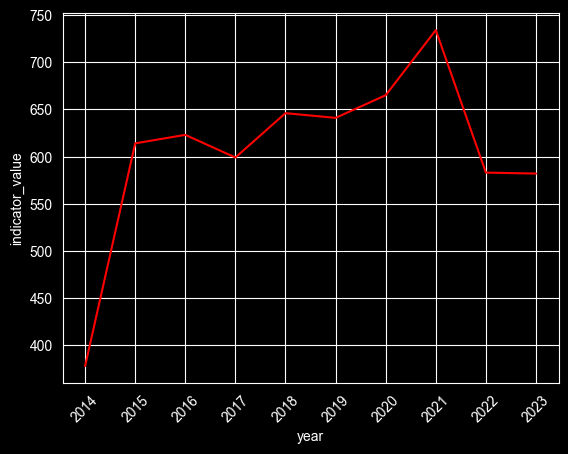

In [27]:
sns.lineplot(count_org,x="year",y="indicator_value",color='red')
plt.xticks(count_org["year"],rotation=45)
plt.show()

Видим резкий рост детей, принятых на воспитание за год, в 2014 и 2015 годах. В 2014 году это связано с увеличением количества детей-сирот в целом (несмотря на экономическую нестабильность, детей-сирот было слишком много). В 2015 году и далее - стабилизация экономической ситуации, курса рубля, понижение безработицы.

In [28]:

count_prinyato_v_sem=data[(data.indicator=='принято детей на воспитание в семьи за отчетный год')& (~data.region.str.contains("Российская Федерация"))].groupby("year")["indicator_value"].sum().reset_index()

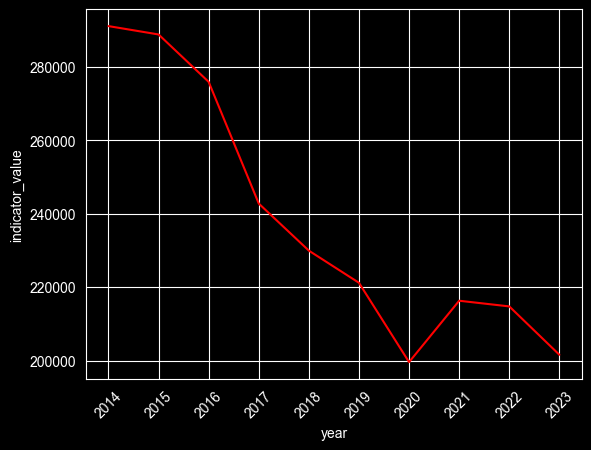

In [29]:
sns.lineplot(count_prinyato_v_sem,x="year",y="indicator_value",color='red')
plt.xticks(count_prinyato_v_sem["year"],rotation=45)
plt.show()

В 2014 году, как было сказано ранее, было резкое падение курса рубля, ухудшение экономической ситуации, рост безработицы. Соответственно отмененных решений о передаче ребенка на воспитание в семью возросло (ведь воспитание ребенка несет за собой большие траты)

In [30]:
count_otmen=data[(data.indicator=='отменено решений о передаче ребенка на воспитание в семью, всего')& (~data.region.str.contains("Российская Федерация"))].groupby("year")["indicator_value"].sum().reset_index()

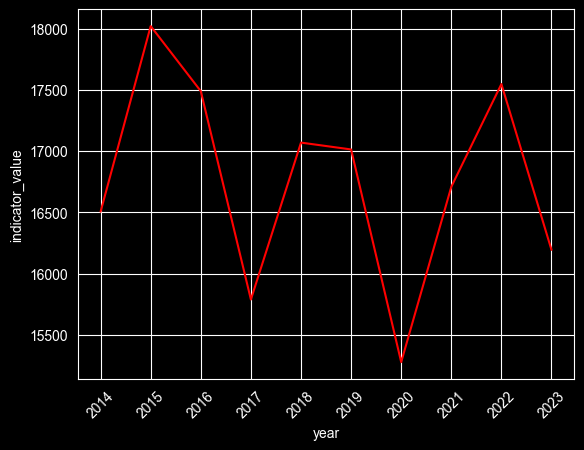

In [31]:
sns.lineplot(count_otmen,x="year",y="indicator_value",color='red')
plt.xticks(count_otmen["year"],rotation=45)
plt.show()

Резкий рост с ~9 000 в 2013 году до пика ~18 000 в 2015-м, вероятно, связан с последствиями Федеральный закон № 272-ФЗ (2013): после запрета иностранного усыновления резко выросло число устройств в российские семьи, а вместе с ним — и число отмен, поскольку система не успела отобрать и подготовить достаточное количество качественных приёмных семей. После 2015 года показатель стабилизировался в диапазоне 15 000–17 000, с провалом в 2020 году (пандемия COVID-19 затормозила судебные и административные процедуры), и вновь вышел на максимумы в 2022-м, что может отражать социальный стресс, вызванный новым экономическим кризисом.

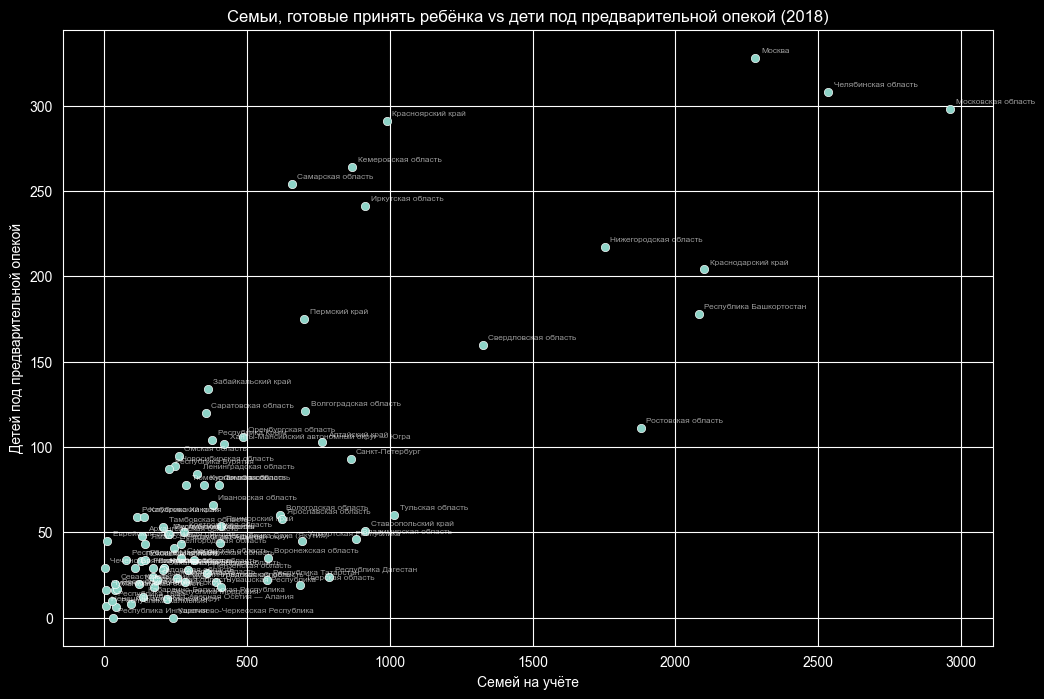

In [32]:
year = 2018

ind_families = 'состоит на учете семей, желающих принять ребенка на воспитание в семью, в органах опеки и попечительства, на конец года, всего'
ind_children = 'находятся под предварительной опекой на конец отчетного года'


families = (
    data[(data.indicator == ind_families) & (data.year == year) & (~data.region.str.contains("Российская Федерация"))].groupby("region")["indicator_value"].sum().reset_index().rename(columns={"indicator_value": "families"})
)

children = (
    data[(data.indicator == ind_children) & (data.year == year) & (~data.region.str.contains("Российская Федерация"))].groupby("region")["indicator_value"].sum().reset_index().rename(columns={"indicator_value": "children"})
)

merged = families.merge(children, on="region").dropna()

fig, ax = plt.subplots(figsize=(12, 8))

sns.scatterplot(data=merged, x="families", y="children", ax=ax)

for _, row in merged.iterrows():
    ax.annotate(row["region"], (row["families"], row["children"]),fontsize=6, alpha=0.6, xytext=(4, 4),textcoords="offset points")

ax.set_title(f"Семьи, готовые принять ребёнка vs дети под предварительной опекой ({year})")
ax.set_xlabel("Семей на учёте")
ax.set_ylabel("Детей под предварительной опекой")
plt.savefig("gr_2018.png", dpi=150, bbox_inches="tight")
plt.show()

В первую очередь прослеживается эффект численности населения, а не экономики: Москва, Московская область, Краснодарский край, Республика Башкортостан закономерно выше остальных просто потому, что они крупнее.
Выбросы из этой логики: Красноярский край и Иркутская область имеют непропорционально высокое число детей под предварительной опекой относительно числа семей на учёте — это может указывать на дефицит готовых принять ребёнка семей в этих регионах при высоком уровне социального неблагополучия. Чеченская Республика и республики Северного Кавказа находятся в левом нижнем углу — там и семей на учёте мало, и детей под предварительной опекой единицы, что отражает культурную специфику: детей традиционно принимают родственники без официального оформления опеки.

In [33]:
piv_tab = data[(data.indicator == "численность усыновленных детей на конец года") & (
    ~data.region.str.contains("Российская Федерация"))].pivot_table(columns="year", index="region",
                                                                    values="indicator_value", aggfunc=sum)

In [34]:
piv_tab

year,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
region,,,,,,,,,,
Алтайский край,396,318,345,255,261,207,192,170,218,135
Амурская область,68,14,12,12,8,0,0,0,2,4
Архангельская область,256,164,119,101,111,117,47,110,107,71
Астраханская область,137,133,83,90,100,42,42,38,34,10
Белгородская область,46,20,37,33,30,20,6,18,25,43
Брянская область,28,22,27,36,36,18,28,20,26,12
Владимирская область,288,195,151,150,127,54,32,60,40,50
Волгоградская область,251,220,180,167,118,135,112,132,60,46
Вологодская область,157,126,109,84,66,78,96,60,63,36


In [35]:
otmeneno = data[data.indicator == "отменено решений о передаче ребенка на воспитание в семью, всего"].groupby(["region","year"])["indicator_value"].sum()

prinyato = data[data.indicator == "принято детей на воспитание в семьи за отчетный год"].groupby(["region","year"])["indicator_value"].sum()

vozvrat = (otmeneno / prinyato * 100).reset_index()
vozvrat.columns = ["region", "year", "koef_vozvrata"]

In [36]:
vozvrat

,region,year,koef_vozvrata
0,Алтайский край,2014,1.686319
1,Алтайский край,2015,2.741493
2,Алтайский край,2016,2.727138
3,Алтайский край,2017,2.827624
4,Алтайский край,2018,7.103825
...,...,...,...
856,Ярославская область,2019,11.124191
857,Ярославская область,2020,6.810740
858,Ярославская область,2021,21.075949
859,Ярославская область,2022,19.178082


region
Вологодская область           15.731312
Курганская область            15.668956
Чукотский автономный округ    15.664771
Липецкая область              15.303313
Республика Хакасия            15.228376
Смоленская область            14.429420
Омская область                14.344321
Калининградская область       14.298532
Ненецкий автономный округ     14.101614
Томская область               13.814609
Name: koef_vozvrata, dtype: float64


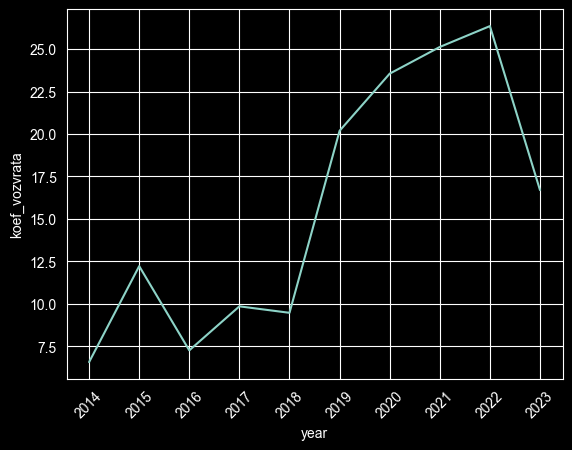

In [37]:

anomaly = vozvrat.groupby("region")["koef_vozvrata"].mean().sort_values(ascending=False)
print(anomaly.head(10))

top_region = anomaly.index[0]

region_data = vozvrat[vozvrat.region == top_region]
sns.lineplot(data=region_data, x="year", y="koef_vozvrata")
plt.xticks(region_data["year"], rotation=45)
plt.show()

Коэффициент возврата в Вологодской области по годам


In [38]:
data[(data.indicator=="численность усыновленных детей на конец года")& (data.year==2013)]

,indicator_code,year,region,okato,oktmo,indicator_category,dimension,main_level,indicator,indicator_value
451204,q913103rik000589,2013,Российская Федерация,0,0,3. Устройство детей в семьи,"устроено в семьи, всего",main,численность усыновленных детей на конец года,8245
462958,q913103rik000624,2013,Российская Федерация,0,0,3. Устройство детей в семьи,устроено в семьи детей до 1 года,main,численность усыновленных детей на конец года,3902
491344,q913103rik000658,2013,Российская Федерация,0,0,3. Устройство детей в семьи,устроено в семьи детей от 1 года до 3 лет,main,численность усыновленных детей на конец года,2234
519928,q913103rik000693,2013,Российская Федерация,0,0,3. Устройство детей в семьи,устроено в семьи детей от 3 до 7 лет,main,численность усыновленных детей на конец года,1497
548512,q913103rik000728,2013,Российская Федерация,0,0,3. Устройство детей в семьи,устроено в семьи детей от 7 лет и старше,main,численность усыновленных детей на конец года,612
577096,q913103rik000763,2013,Российская Федерация,0,0,3. Устройство детей в семьи,устроено в семьи детей-инвалидов,main,численность усыновленных детей на конец года,132


In [39]:
smerti = data[data.indicator == 'умерли'].groupby(["region","year"])["indicator_value"].sum()

v_semyu = data[data.indicator == 'детей, выявленных и учтенных за отчетный год'].groupby(["region","year"])["indicator_value"].sum()

koef = (smerti/ v_semyu *100).reset_index()
koef.columns = ["region", "year", "koef_smerti"]

In [40]:
koef

,region,year,koef_smerti
0,Алтайский край,2014,0.622407
1,Алтайский край,2015,0.700701
2,Алтайский край,2016,1.463964
3,Алтайский край,2017,1.913265
4,Алтайский край,2018,1.934016
...,...,...,...
856,Ярославская область,2019,1.324503
857,Ярославская область,2020,1.204819
858,Ярославская область,2021,0.000000
859,Ярославская область,2022,0.000000
